# MPPI Control Policy with No CBF

### Import necessary packages

In [132]:
import math
import numpy as np
import jax
import jax.numpy as jnp
import dynamaxsys
from dynamaxsys.simplecar import DynamicallyExtendedSimpleCar
import cvxpy as cp

### Make custom dynamics class to track heading rate of change

This dynamics class is based on the DynamicallyExtendedSimpleCar from the dynamaxsys package.

In [133]:
import jax.numpy as jnp
from dynamaxsys.base import Dynamics


class ExtendedCarWithDelta(Dynamics):
    wheelbase: float
    min_max_velocity: tuple

    state_dim: int   # [x, y, theta, v, delta]
    control_dim: int # [delta_dot, a]

    def __init__(self, wheelbase: float, min_max_velocity=(-jnp.inf, jnp.inf)):
        object.__setattr__(self, "wheelbase", wheelbase)
        object.__setattr__(self, "min_max_velocity", min_max_velocity)
        object.__setattr__(self, "state_dim", 5)
        object.__setattr__(self, "control_dim", 2)

        def dynamics_func(state, control, disturbance=None, time=0.0):
            x, y, th, v, delta = state
            delta_dot, a = control

            v = jnp.clip(v, *min_max_velocity)

            dx = v * jnp.cos(th)
            dy = v * jnp.sin(th)
            dth = v / wheelbase * jnp.tan(delta)
            dv = a
            ddelta = delta_dot

            return jnp.array([dx, dy, dth, dv, ddelta])

        super().__init__(
            dynamics_func=dynamics_func,
            state_dim=self.state_dim,
            control_dim=self.control_dim,
        )


### Define robot and human dynamics

In [134]:
# --- Dynamics setup ---
WHEELBASE = 0.5
DT = 0.1

_continuous = ExtendedCarWithDelta(wheelbase=WHEELBASE)
_discrete   = dynamaxsys.get_discrete_time_dynamics(_continuous, DT)

def step_fn(state, control):
    return _discrete(state, control)

# Vectorized version: takes (N, 4) states and (N, 2) controls -> (N, 4) next states
step_batch = jax.vmap(step_fn, in_axes=(0, 0))

### Define MPPI rollout function

In [135]:
# --- MPPI parameters (just what's needed for the rollout) ---
HORIZON    = 50     # planning horizon (steps)
N_SAMPLES  = 500    # number of perturbed trajectories

# Control limits (same as CBF dumb policy)
A_MIN,         A_MAX         = -5.0, 5.0
TAN_DELTA_MIN, TAN_DELTA_MAX = -0.8, 0.8

# Max velocity (same as CBF dumb policy)
V_MAX = 1.6

def rollout_single(state0: jnp.ndarray, controls: jnp.ndarray) -> jnp.ndarray:
    """
    Roll out dynamics from state0 for one sample.

    Args:
        state0:   (4,)           initial state [px, py, theta, v]
        controls: (HORIZON, 2)   control sequence for this sample

    Returns:
        states:   (HORIZON+1, 4) trajectory including the initial state
    """

    # function made to scan through trajectory
    def scan_fn(state, control):
        next_state = step_fn(state, control)
        return next_state, next_state   # (carry, output)

    # scan through trajectory to get all states for proposed policy from mppi
    _, states = jax.lax.scan(scan_fn, state0, controls)
    # states is (HORIZON, 4) — prepend state0 to get full trajectory
    states = jnp.concatenate([state0[None, :], states], axis=0)
    return states   # (HORIZON+1, 4)


# Vectorize over the sample dimension:
# each sample gets the same state0 but a different control sequence
rollout_batch = jax.vmap(rollout_single, in_axes=(None, 0))

# JIT compile for speed — this makes subsequent calls much faster
rollout_batch = jax.jit(rollout_batch)

### Define the cost function used to get the best MPPI trajectories

When the distance between the robot and a human is less than D_SOFT, the cost is:
$Q_{human cost} / d$
where $d$ is the minimum distance between the robot and a human.

jnp.where(dists < D_SOFT,
                  Q_HUMAN_SOFT / jnp.maximum(dists, 1e-6),      # jnp.maximum prevents dividing by zero
                  0.0)

In [136]:
# --- Cost function parameters ---
# Goal
Q_GOAL       = 10.0   # weight on distance to goal at each step
Q_GOAL_FINAL = 50.0   # weight on final state (terminal cost)

# Human proximity
D_SOFT        = 10.0   # soft penalty starts here
D_HARD        = 0.5
Q_HUMAN_SOFT  = 50.0  # weight on soft proximity penalty
Q_HUMAN_HARD  = 1e6    # large finite number standing in for "infinite" cost

# Control effort
Q_CONTROL     = 0.01   # small penalty on large controls


def human_cost_single(pos: jnp.ndarray, human_positions: jnp.ndarray) -> jnp.ndarray:
    """
    Cost at a single robot position due to all humans.

    Args:
        pos:             (2,)         robot [px, py]
        human_positions: (N_HUMANS, 2)

    Returns:
        scalar cost
    """
    # distances from this position to every human: (N_HUMANS,)
    diffs = pos[None, :] - human_positions          # (N_HUMANS, 2)
    dists = jnp.linalg.norm(diffs, axis=1)          # (N_HUMANS,)

    # soft penalty: grows as robot enters D_SOFT radius
    # uses 1/d shape so cost rises steeply close in
    soft = jnp.sum(
        jnp.where(dists < D_SOFT,
                  Q_HUMAN_SOFT / jnp.maximum(dists, 1e-6),      # jnp.maximum prevents dividing by zero
                  0.0)
    )

    hard = jnp.sum(
        jnp.where(dists < D_HARD,
                  Q_HUMAN_HARD / jnp.maximum(dists, 1e-6),      # jnp.maximum prevents dividing by zero
                  0.0)
    )

    return soft + hard


def trajectory_cost(
    trajectory:      jnp.ndarray,   # (HORIZON+1, 4)
    controls:        jnp.ndarray,   # (HORIZON, 2)
    human_positions: jnp.ndarray,   # (N_HUMANS, 2)
    goal:            jnp.ndarray,
) -> jnp.ndarray:
    """
    Total cost for a single sample trajectory.

    Sums three terms over the horizon:
      1. Distance to goal at each step
      2. Human proximity penalty at each step
      3. Control effort
    Plus a terminal goal cost on the final state.
    """

    # --- per-step costs (over steps 0..HORIZON-1) ---
    states = trajectory[:-1]                              # (HORIZON, 4)
    positions = states[:, :2]                             # (HORIZON, 2)

    # 1. goal distance at each step
    goal_dists  = jnp.linalg.norm(positions - goal, axis=1)    # (HORIZON,)
    goal_cost   = Q_GOAL * jnp.sum(goal_dists)

    # 2. human proximity at each step — vmap over timesteps
    human_cost_per_step = jax.vmap(
        human_cost_single, in_axes=(0, None)
    )(positions, human_positions)                               # (HORIZON,)
    human_cost  = jnp.sum(human_cost_per_step)

    # 3. control effort
    control_cost = Q_CONTROL * jnp.sum(controls ** 2)

    # --- terminal cost: heavily penalize distance to goal at final state ---
    final_pos    = trajectory[-1, :2]                          # (2,)
    terminal_cost = Q_GOAL_FINAL * jnp.linalg.norm(final_pos - goal)

    # --- terminal velocity cost: makes robot slow down as it approaches the goal (prevents orbiting the goal) ---
    v = trajectory[:, 3]   # or trajectory[:, 3] if using 4D state

    goal_dist = jnp.linalg.norm(trajectory[-1, :2] - goal)
    stop_weight = jnp.exp(-goal_dist)  # stronger when close

    stop_cost = 10.0 * stop_weight * jnp.sum(v**2)

    return goal_cost + human_cost + control_cost + terminal_cost + stop_cost


# Vectorize over samples: (N_SAMPLES, HORIZON+1, 4) -> (N_SAMPLES,)
cost_batch = jax.vmap(trajectory_cost, in_axes=(0, 0, None, None))
cost_batch = jax.jit(cost_batch)

### Define MPPI step function to update control

In [137]:
import jax.random as jr

# --- MPPI hyperparameters ---
LAMBDA   = 50.0                          # temperature: lower = more greedy
SIGMA    = jnp.array([1.0, 0.5])         # noise std per control dimension [tan_delta, a]
DELTA_DOT_MIN, DELTA_DOT_MAX = -0.5, 0.5

def mppi_step(
    key:      jax.Array,       # JAX random key
    state:    jnp.ndarray,     # current robot state (4,)
    u_nom:    jnp.ndarray,     # nominal control sequence (HORIZON, 2)
    humans:   jnp.ndarray,     # current human positions (N_HUMANS, 2)
    goal:    jnp.ndarray,
) -> tuple[jax.Array, jnp.ndarray, jnp.ndarray]:
    """
    One MPPI planning step.

    Returns:
        new_key:    updated JAX random key
        u_nom:      updated nominal control sequence (HORIZON, 2)
        u_applied:  the single control to apply this timestep (2,)
    """

    # 1. Split key so this call doesn't reuse randomness
    key, subkey = jr.split(key)

    # 2. Sample noise:  (N_SAMPLES, HORIZON, 2)
    E = jr.normal(subkey, shape=(N_SAMPLES, HORIZON, 2)) * SIGMA[None, None, :]

    # 3. Perturb and clip nominal controls
    u_perturbed = u_nom[None, :, :] + E                          # (N_SAMPLES, HORIZON, 2)

    # velocity limit applied to acceleration
    # max a that keeps v <= V_MAX is:
    # a <= (V_MAX - v) / dt
    current_v = state[3]
    a_max_velocity = (V_MAX - current_v) / DT

    u_perturbed = jnp.clip(
        u_perturbed,
        jnp.array([DELTA_DOT_MIN, A_MIN]),
        jnp.array([DELTA_DOT_MAX, jnp.minimum(A_MAX, a_max_velocity)])
    )

    # 4. Roll out all samples from current state
    trajectories = rollout_batch(state, u_perturbed)             # (N_SAMPLES, HORIZON+1, 4)

    # 5. Evaluate cost for each sample
    costs = cost_batch(trajectories, u_perturbed, humans, goal)        # (N_SAMPLES,)

    # 6. Compute weights
    #    Subtract min cost first for numerical stability — stops exp() overflowing
    costs_shifted = costs - costs.min()
    weights = jnp.exp(-costs_shifted / LAMBDA)
    weights = weights / weights.sum()                            # normalize to sum to 1

    # 7. Compute weighted average of perturbed controls
    u_new = jnp.sum(weights[:, None, None] * u_perturbed, axis=0)  # (HORIZON, 2)

    # 8. Extract the control to apply *before* shifting
    u_applied = u_new[0]

    # 9. Shift the nominal sequence forward
    u_nom = jnp.concatenate([u_new[1:], jnp.zeros((1, 2))], axis=0)


    return key, u_nom, u_applied, trajectories, costs

### Simulation loop

In [138]:
import matplotlib.pyplot as plt

# --- World parameters ---
FLOOR_W        = 30.0
FLOOR_H        = 10.0
N_HUMANS       = 4
HUMAN_SPEED    = 2.0    # m/s
GOAL_THRESHOLD = 0.5    # m
MAX_STEPS      = 2000
SEED           = 7

# --- MPPI visualization ---
N_VIZ_SAMPLES = 50     # how many samples to visualize per step
sample_trajs = []   # list of (N_VIZ_SAMPLES, HORIZON+1, 5) arrays
sample_costs = []   # list of (N_VIZ_SAMPLES,) arrays

np.random.seed(SEED)

# --- Initial conditions ---
start_x = np.random.uniform(2.0, FLOOR_W / 3)
start_y = np.random.uniform(2.0, FLOOR_H - 2.0)
state   = jnp.array([start_x, start_y, 0.0, 0.0, 0.0])

GOAL_X  = np.random.uniform(FLOOR_W * 2/3, FLOOR_W - 2.0)
GOAL_Y  = np.random.uniform(2.0, FLOOR_H - 2.0)
goal    = jnp.array([GOAL_X, GOAL_Y])

# --- Humans ---
human_pos = np.column_stack([
    np.random.uniform(FLOOR_W * 0.15, FLOOR_W * 0.85, N_HUMANS),
    np.random.uniform(2.0, FLOOR_H - 2.0, N_HUMANS),
])
human_angles = np.random.uniform(0, 2 * math.pi, N_HUMANS)
human_vel    = np.column_stack([
    HUMAN_SPEED * np.cos(human_angles),
    HUMAN_SPEED * np.sin(human_angles),
])

# --- Storage ---
robot_traj  = [np.array(state)]
human_trajs = [human_pos.copy()]

# --- MPPI state ---
key   = jr.PRNGKey(42)           # separate from numpy seed
u_nom = jnp.zeros((HORIZON, 2)) # warm-started and updated each step

# --- Simulation loop ---
reached = False

for i in range(MAX_STEPS):

    # 1. Move humans (Euler + bounce)
    human_pos = human_pos + human_vel * DT
    for j in range(N_HUMANS):
        if human_pos[j, 0] < 0 or human_pos[j, 0] > FLOOR_W: human_vel[j, 0] *= -1
        if human_pos[j, 1] < 0 or human_pos[j, 1] > FLOOR_H: human_vel[j, 1] *= -1
    human_pos = np.clip(human_pos, [0, 0], [FLOOR_W, FLOOR_H])

    # 2. MPPI step
    key, u_nom, u_applied, trajectories, costs = mppi_step(
        key, state, u_nom, jnp.array(human_pos), goal
    )

    # 3. Step robot dynamics
    state = step_fn(state, u_applied)

    # 4. Store
    robot_traj.append(np.array(state))
    human_trajs.append(human_pos.copy())

    # randomly pick N_VIZ_SAMPLES to store
    idx = np.random.choice(N_SAMPLES, N_VIZ_SAMPLES, replace=False)
    sample_trajs.append(np.array(trajectories[idx]))
    sample_costs.append(np.array(costs[idx]))

    # 5. Termination
    dist_to_goal = jnp.linalg.norm(state[:2] - goal)
    if dist_to_goal < GOAL_THRESHOLD:
        print(f'Goal reached at step {i+1},  t = {(i+1)*DT:.1f} s')
        reached = True
        break

    # 6. Optional progress log every 100 steps
    if (i + 1) % 100 == 0:
        print(f'Step {i+1:4d}  |  t = {(i+1)*DT:5.1f} s  |  '
              f'dist to goal = {dist_to_goal:.2f} m  |  '
              f'v = {float(state[3]):.2f} m/s')

else:
    print(f'Max steps ({MAX_STEPS}) reached without finding the goal.')

# cast from lists to np arrays
human_trajs = np.array(human_trajs)
robot_traj  = np.array(robot_traj)
sample_trajs = np.array(sample_trajs)   # (T, N_VIZ_SAMPLES, HORIZON+1, 5)
sample_costs = np.array(sample_costs)   # (T, N_VIZ_SAMPLES)

print(type(robot_traj))
robot_traj.shape


Step  100  |  t =  10.0 s  |  dist to goal = 7.55 m  |  v = 1.59 m/s
Goal reached at step 153,  t = 15.3 s
<class 'numpy.ndarray'>


(154, 5)

### Animate simulation

This animation includes:
* The robot
* The human obstacles with their soft safeout distance labeled
* The goal
* 50 random trajectories in the 500 trajectory sample with color coding to show which have higher/lower costs

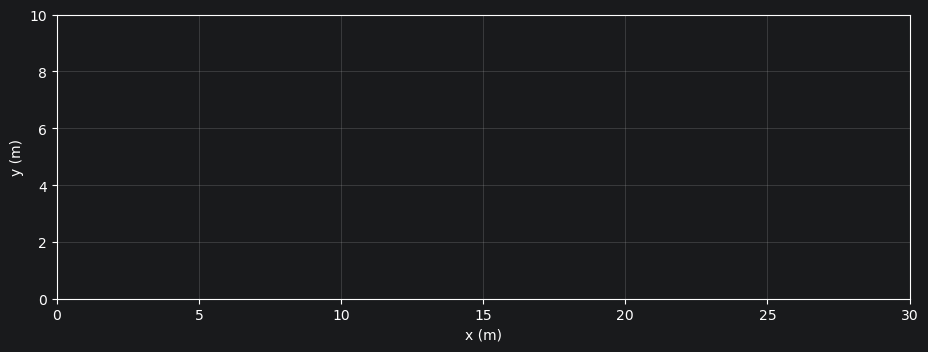

In [139]:
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 50  # MB

ROBOT_BODY_R = 0.8
HUMAN_BODY_R = 0.5
ANIM_EVERY   = 3   # animate every Nth step to keep file size down

fig, ax = plt.subplots(figsize=(11, 7))

def init():
    ax.clear()
    ax.set_xlim([0, FLOOR_W])
    ax.set_ylim([0, FLOOR_H])
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    return []

def animate(i):
    ax.clear()
    ax.set_xlim([0, FLOOR_W])
    ax.set_ylim([0, FLOOR_H])
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')

    # --- goal ---
    ax.plot(GOAL_X, GOAL_Y, marker='*', ms=16, color='green', zorder=10, label='Goal')
    ax.add_patch(plt.Circle((GOAL_X, GOAL_Y), GOAL_THRESHOLD, color='green', alpha=0.2))

    # --- CBF zones + human trajectories + human bodies ---
    humans = human_trajs[i]
    for j in range(N_HUMANS):
        hx, hy = humans[j]
        ax.add_patch(plt.Circle((hx, hy), D_SOFT, color='C1', alpha=0.06, zorder=1))
        lbl_traj = 'Human Traj' if j == 0 else '_nolegend_'
        ax.plot(human_trajs[:i+1, j, 0], human_trajs[:i+1, j, 1],
                'o-', markersize=2, color='C1', alpha=0.35, label=lbl_traj)
        ax.add_patch(plt.Circle((hx, hy), HUMAN_BODY_R, color='C1', alpha=0.8, zorder=5))
        lbl_pt = 'Human' if j == 0 else '_nolegend_'
        ax.scatter([hx], [hy], s=20, color='C1', zorder=6, label=lbl_pt)

    # --- robot trajectory ---
    ax.plot(robot_traj[:i+1, 0], robot_traj[:i+1, 1],
            'o-', markersize=2, color='C0', alpha=0.5, label='Robot Traj')

    # --- robot body + heading arrow ---
    rx, ry, theta, v, delta = robot_traj[i]
    ax.add_patch(plt.Circle((rx, ry), ROBOT_BODY_R, color='C0', alpha=0.75, zorder=7))
    ax.scatter([rx], [ry], s=20, color='C0', zorder=8, label='Robot')
    arrow_len = 2.0
    ax.annotate('',
        xy=(rx + arrow_len * math.cos(theta), ry + arrow_len * math.sin(theta)),
        xytext=(rx, ry),
        arrowprops=dict(arrowstyle='->', color='white', lw=2.0),
        zorder=9)

    # --- MPPI sample trajectories ---
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize

    s_trajs = sample_trajs[i]   # (N_VIZ_SAMPLES, HORIZON+1, 5)
    s_costs = sample_costs[i]   # (N_VIZ_SAMPLES,)

    norm = Normalize(vmin=s_costs.min(), vmax=s_costs.min() + 500)
    cmap = plt.cm.RdYlGn_r      # red = high cost, green = low cost

    for k in range(N_VIZ_SAMPLES):
        color = cmap(norm(s_costs[k]))
        ax.plot(s_trajs[k, :, 0], s_trajs[k, :, 1],
                '-', lw=0.6, alpha=0.3, color=color, zorder=3)

    # plot the single best sample on top
    best_k = s_costs.argmin()
    ax.plot(s_trajs[best_k, :, 0], s_trajs[best_k, :, 1],
            '-', lw=1.5, alpha=0.8, color='cyan',
            label='Best sample', zorder=4)

    ax.set_title(
        f't = {i*DT:.1f} s    '
        f'heading = {math.degrees(theta):.1f}°    '
        f'velocity = {v:.2f} m/s    '
        f'dist to goal = {np.linalg.norm(np.array([rx, ry]) - np.array([GOAL_X, GOAL_Y])):.1f} m'
    )
    ax.legend(loc='upper left', fontsize=8)

ani = animation.FuncAnimation(
    fig, animate,
    frames=range(0, len(sample_trajs), ANIM_EVERY),
    init_func=init,
    interval=100,
    blit=False,
    repeat=True,
)

HTML(ani.to_jshtml())
# ani.save("mppi_policy.gif", writer="pillow", fps=10)

## Policy Evaluation

Run N simulations with randomized starting conditions for both the MPPI and CBF policies, then compare safety metrics across all runs.

### Define straight line control policy with CBF

In [140]:
WHEELBASE   = 1.0      # L
DT          = 0.05     # timestep (seconds)
MAX_STEPS   = 2000     # hard cutoff in case goal is never reached

# Nominal policy
V_DESIRED   = 1.6      # m/s cruise speed
K_V         = 2.0      # P-gain for speed controller
K_THETA     = 2.0      # P-gain for angular controller

# Goal location
GOAL_X = 1.0
GOAL_Y = 1.0

# CBF parameters
D_STOP      = 3.0      # distance at which v_max = 0
D_SLOW      = 10.0     # distance at which v_max = V_DESIRED (full speed allowed)
ALPHA       = 1.5      # CBF class-K gain (higher = more aggressive recovery)

# Control limits
A_MIN, A_MAX         = -5.0, 5.0
TAN_DELTA_MIN, TAN_DELTA_MAX = -0.8, 0.8

# define maximum velocity based on proximity to human obstacle
def v_max(d):
    """Maximum velocity based on proximity to human obstacle."""
    if d <= D_STOP:
        return 0.0
    elif d <= D_SLOW:
        return 1/2 * V_DESIRED
    return V_DESIRED

# define derivative of v_max with respect to d to make robot slow down as it approaches the barrier of the velocity ranges
def dv_max_dd(d: float) -> float:
    """Derivative of v_max with respect to d."""
    if d <= D_STOP or d >= D_SLOW:
        return 0.0
    return V_DESIRED / (D_SLOW - D_STOP)

# function to compute the CBF constraint coefficients
def cbf_constraint_coeffs(state: np.ndarray, human_pos: np.ndarray):
    """
    Returns (lhs_a_coeff, rhs) such that the CBF condition is:
        lhs_a_coeff * a  >=  rhs

    The constraint is:  dh/dt + alpha*h >= 0
    where h = v_max(d) - v, dh/dt = dv_max_dd * d_dot - a

    lhs_a_coeff is always -1 (the constraint is:  -a + ... >= -alpha*h)
    rhs = -alpha*h - dv_max_dd * d_dot
    """
    px, py, theta, v, delta = state
    phx, phy = human_pos

    diff = np.array([px - phx, py - phy])
    d = np.linalg.norm(diff)

    # Avoid division by zero
    if d < 1e-6:
        d = 1e-6

    h = v_max(d) - v

    # Time derivative of d:  d_dot = (diff / d) . [v cos(theta), v sin(theta)]
    vel_vec = np.array([v * math.cos(theta), v * math.sin(theta)])
    d_dot = (diff / d) @ vel_vec

    # dh/dt = dh_dt_free - a  (control enters only through 'a')
    # Condition: dh_dt_free - a + alpha * h >= 0
    # =>  -a >= -alpha*h - dh_dt_free
    # =>  a  <=  alpha*h + dh_dt_free          (rewrite as <=)
    upper_bound_on_a = ALPHA * h + dv_max_dd(d) * d_dot

    return upper_bound_on_a, h, d


import cvxpy as cp

# build the QP once outside cbf_control
_u     = cp.Variable(2)
_u_nom = cp.Parameter(2)
_ubs   = [cp.Parameter() for _ in range(N_HUMANS)]   # one upper bound per human

_constraints = [
    _u[0] >= TAN_DELTA_MIN,
    _u[0] <= TAN_DELTA_MAX,
    _u[1] >= A_MIN,
    _u[1] <= A_MAX,
] + [_u[1] <= ub for ub in _ubs]

_prob = cp.Problem(cp.Minimize(cp.sum_squares(_u - _u_nom)), _constraints)

def cbf_control(state, humans, goal_x, goal_y):
    px, py, theta, v, delta = state

    a_nom = float(np.clip(K_V * (V_DESIRED - v), A_MIN, A_MAX))
    tan_delta_nom = 0.0   # straight line nominal
    _u_nom.value = np.array([tan_delta_nom, a_nom])

    diags = []
    for i, h_pos in enumerate(humans):
        ub, h_val, d = cbf_constraint_coeffs(state, h_pos)
        _ubs[i].value = float(ub)
        diags.append({'d': d, 'h': h_val, 'a_ub': ub})

    _prob.solve(solver=cp.CLARABEL, verbose=False, warm_start=True)

    if _prob.status not in ('optimal', 'optimal_inaccurate'):
        return np.array([0.0, A_MIN]), diags

    return _u.value, diags

### Metric computation and single-simulation runner

In [141]:
import math
from dataclasses import dataclass

@dataclass
class SimResult:
    success:        bool
    n_collisions:   int
    time_to_goal:   float   # nan if goal not reached
    path_length:    float
    min_dist_human: float


def compute_metrics(robot_traj, human_trajs, goal, dt,
                    goal_threshold, collision_radius):
    """
    Compute all safety metrics from a completed trajectory.

    Args:
        robot_traj:       (T, 4or5)     robot states
        human_trajs:      (T, N_H, 2)   human positions at each step
        goal:             (2,)           goal position
        dt:               float
        goal_threshold:   float          distance that counts as reaching goal
        collision_radius: float          distance that counts as a collision
    """
    positions = robot_traj[:, :2]   # (T, 2)

    # --- success ---
    dists_to_goal = np.linalg.norm(positions - goal, axis=1)   # (T,)
    success = bool(dists_to_goal.min() < goal_threshold)

    # --- time to goal ---
    if success:
        first_reach = int(np.argmax(dists_to_goal < goal_threshold))
        time_to_goal = first_reach * dt
    else:
        time_to_goal = float('nan')

    # --- path length ---
    deltas = np.diff(positions, axis=0)             # (T-1, 2)
    path_length = float(np.sum(np.linalg.norm(deltas, axis=1)))

    # --- per-timestep distance to nearest human: (T,) ---
    # human_trajs: (T, N_H, 2),  positions: (T, 2)
    dists_to_humans = np.linalg.norm(
        positions[:, None, :] - human_trajs,   # (T, N_H, 2)
        axis=2
    ).min(axis=1)                               # (T,) min over humans

    min_dist_human = float(dists_to_humans.min())

    # --- collision count ---
    # count distinct entries into the collision zone (False->True transitions)
    in_collision = dists_to_humans < collision_radius          # (T,) bool
    entries = np.diff(in_collision.astype(int))
    n_collisions = int(np.sum(entries > 0))

    return SimResult(
        success=success,
        n_collisions=n_collisions,
        time_to_goal=time_to_goal,
        path_length=path_length,
        min_dist_human=min_dist_human,
    )


def run_one_simulation(policy, seed, floor_w, floor_h, n_humans,
                       human_speed, max_steps, dt, goal_threshold):
    """
    Run a single simulation with a given policy object.
    Policy must implement .init(state, goal) and .step(state, extra, humans, goal).
    Returns (SimResult, robot_traj, human_trajs).
    """
    np.random.seed(seed)

    # --- randomize scenario ---
    start = np.array([
        np.random.uniform(2.0, floor_w / 3),
        np.random.uniform(2.0, floor_h - 2.0),
        0.0, 0.0, 0.0   # [px, py, theta, v, delta]
    ])
    goal = np.array([
        np.random.uniform(floor_w * 2/3, floor_w - 2.0),
        np.random.uniform(2.0, floor_h - 2.0),
    ])
    human_pos = np.column_stack([
        np.random.uniform(floor_w * 0.15, floor_w * 0.85, n_humans),
        np.random.uniform(2.0, floor_h - 2.0, n_humans),
    ])
    human_angles = np.random.uniform(0, 2 * math.pi, n_humans)
    human_vel = np.column_stack([
        human_speed * np.cos(human_angles),
        human_speed * np.sin(human_angles),
    ])

    state = jnp.array(start)
    extra = policy.init(state, goal)

    robot_traj  = [np.array(state)]
    human_trajs = [human_pos.copy()]

    for i in range(max_steps):
        # move humans
        human_pos = human_pos + human_vel * dt
        for j in range(n_humans):
            if human_pos[j, 0] < 0 or human_pos[j, 0] > floor_w: human_vel[j, 0] *= -1
            if human_pos[j, 1] < 0 or human_pos[j, 1] > floor_h: human_vel[j, 1] *= -1
        human_pos = np.clip(human_pos, [0, 0], [floor_w, floor_h])

        # get control
        control, extra = policy.step(state, extra, jnp.array(human_pos), goal)

        # step dynamics
        state = step_fn(state, control)

        robot_traj.append(np.array(state))
        human_trajs.append(human_pos.copy())

        if np.linalg.norm(np.array(state[:2]) - goal) < goal_threshold:
            break

    robot_traj  = np.array(robot_traj)
    human_trajs = np.array(human_trajs)

    result = compute_metrics(
        robot_traj, human_trajs, goal, dt,
        goal_threshold, collision_radius=D_HARD
    )
    return result, robot_traj, human_trajs


def run_evaluation(policy, n_sims, seeds, floor_w, floor_h,
                   n_humans, human_speed, max_steps, dt, goal_threshold):
    """
    Run n_sims simulations and return aggregated metrics with SEM.
    Uses the same seeds for both policies so scenarios are identical.
    """
    results = []
    for i, seed in enumerate(seeds):
        result, _, _ = run_one_simulation(
            policy, seed, floor_w, floor_h, n_humans,
            human_speed, max_steps, dt, goal_threshold
        )
        results.append(result)
        if (i + 1) % 10 == 0:
            print(f'  {i+1}/{n_sims} simulations complete')

    # --- aggregate ---
    n = len(results)
    successes    = np.array([r.success        for r in results], dtype=float)
    collisions   = np.array([r.n_collisions   for r in results], dtype=float)
    times        = np.array([r.time_to_goal   for r in results], dtype=float)
    path_lengths = np.array([r.path_length    for r in results], dtype=float)
    min_dists    = np.array([r.min_dist_human for r in results], dtype=float)

    # time_to_goal: only average over successful runs
    times_valid = times[~np.isnan(times)]

    def mean_sem(arr):
        return float(np.mean(arr)), float(np.std(arr) / np.sqrt(len(arr)))

    summary = {
        'success_rate':      mean_sem(successes),
        'mean_collisions':   mean_sem(collisions),
        'mean_time_to_goal': mean_sem(times_valid) if len(times_valid) > 0
                             else (float('nan'), float('nan')),
        'mean_path_length':  mean_sem(path_lengths),
        'mean_min_dist':     mean_sem(min_dists),
    }
    return summary, results


### Define policy wrappers

Each policy is wrapped in a class with `.init()` and `.step()` so the evaluation loop can call them identically.

In [142]:
class MPPIPolicy:
    """Wraps mppi_step for use in the evaluation loop."""

    def init(self, state, goal):
        # extra state: (jax_key, u_nom, goal)
        return (jr.PRNGKey(0), jnp.zeros((HORIZON, 2)), jnp.array(goal))

    def step(self, state, extra, humans, goal):
        key, u_nom, _ = extra
        key, u_nom, u_applied, _, _ = mppi_step(
            key, state, u_nom, humans, jnp.array(goal)
        )
        return u_applied, (key, u_nom, jnp.array(goal))


class CBFNominalPolicy:
    """CBF with the simple straight-line nominal policy (no goal-seeking steering)."""

    def init(self, state, goal):
        return jnp.array(goal)

    def step(self, state, extra, humans, goal):
        u, _ = cbf_control(
            np.array(state),
            np.array(humans),
            float(goal[0]),
            float(goal[1])
        )
        return jnp.array(u), jnp.array(goal)


### Run evaluations

Uses the same 100 seeds for both policies so every simulation has identical starting conditions. This ensures differences in metrics reflect the policies, not randomness in the scenarios.

In [143]:
N_SIMS = 100
seeds  = list(range(N_SIMS))   # seeds 0-99, shared across both policies

print('Evaluating MPPI policy...')
mppi_summary, mppi_results = run_evaluation(
    MPPIPolicy(), N_SIMS, seeds,
    FLOOR_W, FLOOR_H, N_HUMANS, HUMAN_SPEED, MAX_STEPS, DT, GOAL_THRESHOLD
)

print('Evaluating dumb policy with CBF...')
cbf_nom_summary, cbf_nom_results = run_evaluation(
    CBFNominalPolicy(), N_SIMS, seeds,
    FLOOR_W, FLOOR_H, N_HUMANS, HUMAN_SPEED, MAX_STEPS, DT, GOAL_THRESHOLD
)

print('\nDone.')

Evaluating MPPI policy...
  10/100 simulations complete
  20/100 simulations complete
  30/100 simulations complete
  40/100 simulations complete
  50/100 simulations complete
  60/100 simulations complete
  70/100 simulations complete
  80/100 simulations complete
  90/100 simulations complete
  100/100 simulations complete
Evaluating dumb policy with CBF...
  10/100 simulations complete
  20/100 simulations complete
  30/100 simulations complete
  40/100 simulations complete
  50/100 simulations complete
  60/100 simulations complete
  70/100 simulations complete
  80/100 simulations complete
  90/100 simulations complete
  100/100 simulations complete

Done.


### Results table

In [144]:
policies  = ['CBF', 'MPPI']
summaries = [cbf_nom_summary, mppi_summary]

metric_keys = [
    'success_rate',
    'mean_collisions',
    'mean_time_to_goal',
    'mean_path_length',
    'mean_min_dist',
]
metric_labels = [
    'Success Rate',
    'Mean Collisions',
    'Mean Time to Goal (s)',
    'Mean Path Length (m)',
    'Mean Min Dist to Human (m)',
]

print(f"{'Metric':<30} {'CBF':>22} {'MPPI':>22}")
print('-' * 76)
for label, key in zip(metric_labels, metric_keys):
    cbf_mean,  cbf_sem  = cbf_nom_summary[key]
    mppi_mean, mppi_sem = mppi_summary[key]
    cbf_str  = f'{cbf_mean:.3f} ± {cbf_sem:.3f}'
    mppi_str = f'{mppi_mean:.3f} ± {mppi_sem:.3f}'
    print(f'{label:<30} {cbf_str:>22} {mppi_str:>22}')

Metric                                            CBF                   MPPI
----------------------------------------------------------------------------
Success Rate                            0.160 ± 0.037          1.000 ± 0.000
Mean Collisions                         0.930 ± 0.100          0.110 ± 0.040
Mean Time to Goal (s)                  22.916 ± 1.817          5.901 ± 0.476
Mean Path Length (m)                  220.030 ± 9.027         36.806 ± 2.270
Mean Min Dist to Human (m)              0.686 ± 0.082          1.459 ± 0.079


### Results bar chart

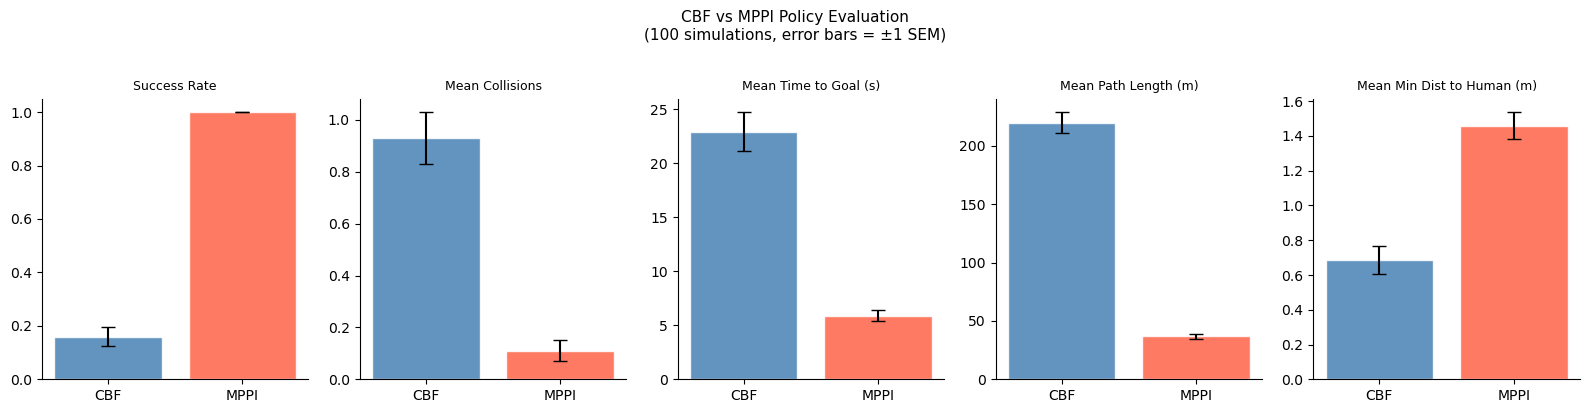

In [146]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

policies  = ['CBF', 'MPPI']
summaries = [cbf_nom_summary, mppi_summary]
colors    = ['steelblue', 'tomato']

for ax, label, key in zip(axes, metric_labels, metric_keys):
    means = [s[key][0] for s in summaries]
    sems  = [s[key][1] for s in summaries]
    bars  = ax.bar(policies, means, yerr=sems, color=colors,
                   capsize=5, alpha=0.85, edgecolor='white')
    ax.set_title(label, fontsize=9)
    ax.set_ylabel('')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('CBF vs MPPI Policy Evaluation\n'
             f'({N_SIMS} simulations, error bars = ±1 SEM)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()